<a href="https://colab.research.google.com/github/Likelipop/01-NLP/blob/main/week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem
- Use BERT and XLNet to classify sentiment from vietnamese students reviews.

## Download dataset
Vietnamese Students' Feedback Corpus (UIT-VSFC) is the resource consists of over 16,000 sentences which are human-annotated with two different tasks: sentiment-based and topic-based classifications.

[1] Kiet Van Nguyen, Vu Duc Nguyen, Phu Xuan-Vinh Nguyen, Tham Thi-Hong Truong, Ngan Luu-Thuy Nguyen, UIT-VSFC: Vietnamese Students' Feedback Corpus for Sentiment Analysis,  2018 10th International Conference on Knowledge and Systems Engineering (KSE 2018), November 1-3, 2018, Ho Chi Minh City, Vietnam

In [ ]:
!pip install prettytable

In [1]:
!pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 1

In [35]:
#Dataset preparation
from datasets import load_dataset
from collections import Counter
#Model
from multiprocessing import Value
from torch.utils.data import Dataset
import torch
from transformers  import AutoTokenizer
# Display
import matplotlib.pyplot as plt
import seaborn as sns
from prettytable import PrettyTable

## DATA PREPARATION

## Custom dataset

In [40]:
class Mydataset(Dataset):

  def __init__(self, dataset_name : str,
               tokenizer_name: str,
               max_length : int,
               target_name = "sentiment") :
      """
      Args:
        name (str): The dataset name to load from hugging_face
        tokenizer_name (str): NName of the Hugging Face tokenizer to use
        max_length (int):Maximum sequence length for tokenization.
      """

      super().__init__()

      #1. Load the Hugging Face dataset
      self.mydataset = load_dataset(dataset_name)
      print(f"loading {dataset_name} successfully")
      self.train_set = self.mydataset["train"]
      self.test_set = self.mydataset["test"]
      print(f"splitting dataset successfully")

      #2. Load the tokenizer and do some initialize thing
      self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
      print(f"loading {tokenizer_name} successfully")
      self.max_length = max_length

      #3. Create label mapping for labels (incase it was not numeric value)
      self.label_names = self.train_set.features[target_name].names
      self.label_to_id = {label : i for i,label in enumerate(self.label_names)}
      self.id_to_label = {i: label for i, label in enumerate(self.label_names)}
      self.num_labels = len(self.label_names)

  def __len__(self):

    """
    returns the total number of samples in dataset.
    """
    return len(self.mydataset)

  def __getitem__(self,idx):
    """
    returns a signle processed sample from the dataset at the given index.
    Args:
      idx (int): Index of the sample to retrieve.
    Returns:
      dict: A dictionary containing:
        - 'input_ids': Tokenized input setence.
        - 'attention_mask': Attention mask for the tokenizeed sentence.
        - 'labels': Integer representation of the sentiment label.
    """

    # 1. Take out the sample arcoding to the given index idx
    sample = self.mydataset[idx]
    sentence = sample['sentence']
    sentiment_str = sample['sentiment']

    # 2. Extract the label, we convert it into numeric value incase it was string.
    if isinstance(sentiment_str, str):
      label_id = self.label_to_id[sentiment_str]
    elif isinstance(sentiment_str, int):
      label_id = sentiment_str
    else :
      raise ValueError(f"Unexpected sentiment type: {type(sentiment_str)} for value {sentiment_str}")

    #3. tokenize the sentence
    encoding = self.tokenizer(
        sentence,
        padding = 'max_length',
        truncation = True,
        max_length = self.max_length,
        return_attention_mask = True,
        return_tensors = 'pt'
    )

    return {
        'input_ids': encoding['input_ids'].squeeze(0),
        'attention_mask': encoding['attention_mask'].squeeze(0),
        'labels' : torch.tensor(label_id, dtype = torch.long)}

  def visualization(self):
      """
      Visualize dataset's distribution.
      """
      feature_to_plot = set(self.train_set.features)
      _, axes = plt.subplots(ncols = 2, nrows = len(feature_to_plot), figsize = (5*len(feature_to_plot),10))

      for i, feature in enumerate(feature_to_plot):
        train_counter = Counter(self.train_set[feature])
        test_counter  = Counter(self.test_set[feature])

        sns.histplot(train_counter, ax = axes[i,0]).set_title(f"training's + {feature}")
        sns.histplot(test_counter, ax = axes[i,1]).set_title(f"test's + {feature}")

      plt.show()



In [41]:
vi_dataset = Mydataset(
    dataset_name="uitnlp/vietnamese_students_feedback",
    tokenizer_name="vinai/phobert-base",
    max_length=128)


loading uitnlp/vietnamese_students_feedback successfully
splitting dataset successfully
loading vinai/phobert-base successfully


In [42]:
# Select 5 samples from train and test sets
train_samples = vi_dataset.train_set.select(range(5))
test_samples = vi_dataset.test_set.select(range(5))

# Create a table for each set
train_table = PrettyTable()
test_table = PrettyTable()

# Set field names (columns) based on dataset features
train_table.field_names = train_samples.column_names
test_table.field_names = test_samples.column_names

# Add rows to the tables
for sample in train_samples:
  train_table.add_row([sample[col] for col in train_samples.column_names])

for sample in test_samples:
  test_table.add_row([sample[col] for col in test_samples.column_names])

# Display
print("Training samples")
print(train_table)

print("Testing samples")
print(test_table)

Training samples
+------------------------------------------------------------------------------+-----------+-------+
|                                   sentence                                   | sentiment | topic |
+------------------------------------------------------------------------------+-----------+-------+
|                          slide giáo trình đầy đủ .                           |     2     |   1   |
|                nhiệt tình giảng dạy , gần gũi với sinh viên .                |     2     |   0   |
|                     đi học đầy đủ full điểm chuyên cần .                     |     0     |   1   |
| chưa áp dụng công nghệ thông tin và các thiết bị hỗ trợ cho việc giảng dạy . |     0     |   0   |
|         thầy giảng bài hay , có nhiều bài tập ví dụ ngay trên lớp .          |     2     |   0   |
+------------------------------------------------------------------------------+-----------+-------+
Testing samples
+---------------------------------------------------------

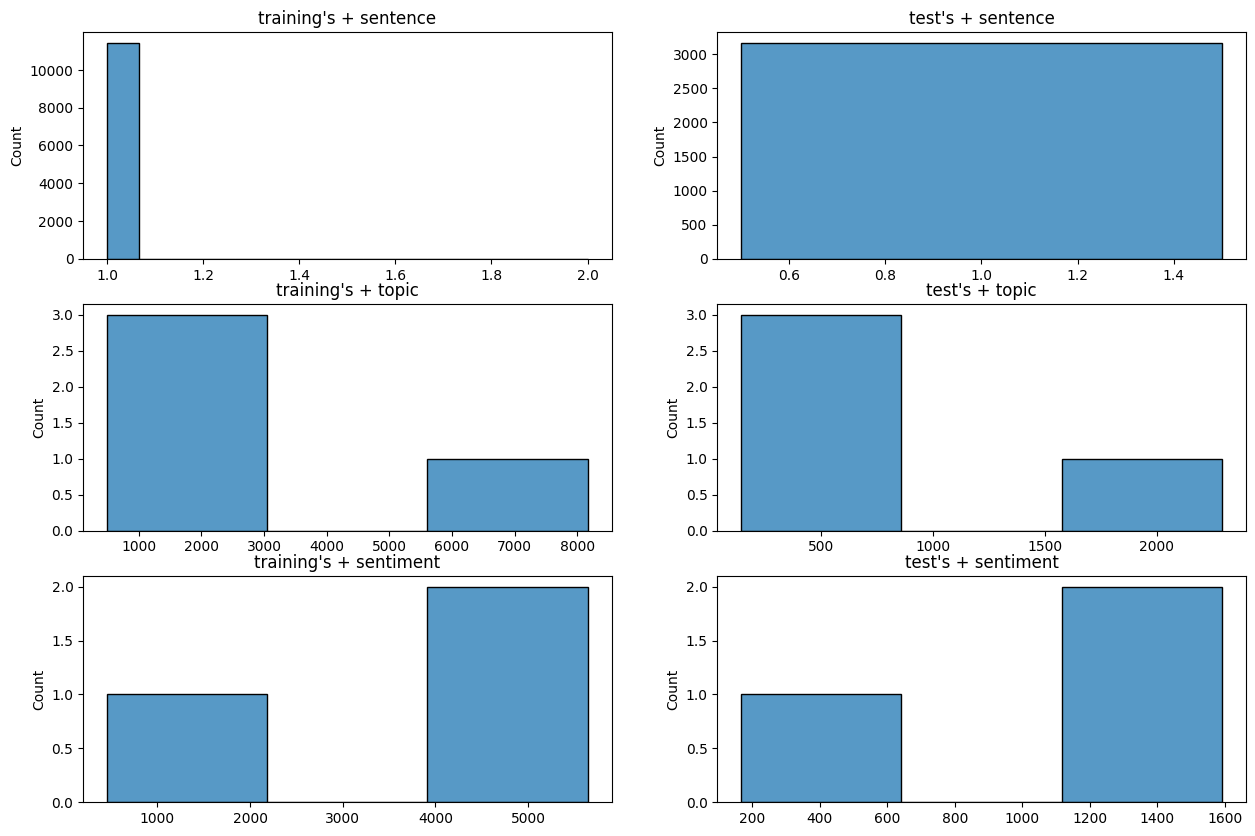

In [43]:
vi_dataset.visualization()

In [ ]:
import torch
from torch.utils.data import Dataset
from datasets import load_dataset, ClassLabel, DatasetDict, Dataset as HuggingFaceDataset
from transformers import AutoTokenizer, PreTrainedTokenizerBase
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, List, Tuple, Optional, Union, Any

class FlexibleDataset(Dataset):
    """
    A flexible PyTorch Dataset for text classification tasks, designed to work
    with Hugging Face datasets and tokenizers.

    Each instance of this class represents a specific split (e.g., "train", "test").
    """

    def __init__(self,
                 hf_dataset_or_path: Union[str, DatasetDict, HuggingFaceDataset],
                 tokenizer: PreTrainedTokenizerBase,
                 max_length: int,
                 text_column: str = "text", # Default text column name
                 label_column: str = "label", # Default label column name
                 split: Optional[str] = None, # e.g., "train", "test", "validation"
                 label_map: Optional[Dict[str, int]] = None,
                 id_to_label: Optional[Dict[int, str]] = None,
                 num_labels: Optional[int] = None):
        """
        Args:
            hf_dataset_or_path (Union[str, DatasetDict, HuggingFaceDataset]):
                Path/name of the Hugging Face dataset, a pre-loaded DatasetDict,
                or a specific HuggingFaceDataset split.
            tokenizer (PreTrainedTokenizerBase): An initialized Hugging Face tokenizer.
            max_length (int): Maximum sequence length for tokenization.
            text_column (str): The name of the column containing the input text.
            label_column (str): The name of the column containing the labels.
            split (Optional[str]): The specific dataset split to use (e.g., "train").
                If hf_dataset_or_path is already a specific split, this can be None.
            label_map (Optional[Dict[str, int]]): Pre-computed mapping from label names to IDs.
            id_to_label (Optional[Dict[int, str]]): Pre-computed mapping from IDs to label names.
            num_labels (Optional[int]): Pre-computed number of unique labels.
        """
        super().__init__()

        self.tokenizer = tokenizer
        self.max_length = max_length
        self.text_column = text_column
        self.label_column = label_column

        # 1. Load and select the dataset split
        if isinstance(hf_dataset_or_path, str):
            print(f"Loading dataset '{hf_dataset_or_path}'...")
            full_dataset = load_dataset(hf_dataset_or_path)
        elif isinstance(hf_dataset_or_path, (DatasetDict, HuggingFaceDataset)):
            full_dataset = hf_dataset_or_path
        else:
            raise TypeError("hf_dataset_or_path must be a string, DatasetDict, or HuggingFaceDataset.")

        if isinstance(full_dataset, DatasetDict):
            if split is None:
                raise ValueError("A 'split' name (e.g., 'train') must be provided if hf_dataset_or_path is a DatasetDict.")
            if split not in full_dataset:
                raise ValueError(f"Split '{split}' not found in dataset. Available splits: {list(full_dataset.keys())}")
            self.data = full_dataset[split]
            print(f"Using split '{split}' from the dataset.")
        elif isinstance(full_dataset, HuggingFaceDataset):
            self.data = full_dataset # Assume it's already the desired split
            if split:
                print(f"Warning: 'split' argument '{split}' provided but hf_dataset_or_path is already a single HuggingFaceDataset. Using the provided dataset directly.")
            print("Using the provided HuggingFaceDataset split.")
        else:
            # This case should ideally not be reached if the type check above is comprehensive
            raise TypeError("Processed full_dataset is not of expected type.")


        if self.text_column not in self.data.column_names:
            raise ValueError(f"Text column '{self.text_column}' not found. Available columns: {self.data.column_names}")
        if self.label_column not in self.data.column_names:
            raise ValueError(f"Label column '{self.label_column}' not found. Available columns: {self.data.column_names}")

        # 2. Initialize label mapping
        # Priority: Provided maps > HF features > Infer from data
        if label_map and id_to_label and num_labels is not None:
            self.label_to_id = label_map
            self.id_to_label = id_to_label
            self.num_labels = num_labels
            self.label_names = [self.id_to_label[i] for i in range(self.num_labels)]
            print("Using pre-computed label mappings.")
        else:
            self._initialize_label_properties()
            print(f"Initialized label properties: {self.num_labels} labels - {self.label_names}")

    def _initialize_label_properties(self):
        """Helper to initialize label_to_id, id_to_label, and num_labels."""
        feature_info = self.data.features[self.label_column]
        if isinstance(feature_info, ClassLabel):
            self.label_names = feature_info.names
            self.label_to_id = {name: i for i, name in enumerate(self.label_names)}
            self.id_to_label = {i: name for i, name in enumerate(self.label_names)}
            self.num_labels = feature_info.num_classes
            print(f"Inferred labels from ClassLabel feature: '{self.label_column}'")
        else:
            # Infer from unique values if not a ClassLabel (e.g., plain integers or strings)
            print(f"Warning: Label column '{self.label_column}' is not a ClassLabel. Attempting to infer labels from unique values.")
            unique_labels = sorted(list(set(self.data[self.label_column])))

            if not unique_labels:
                raise ValueError(f"No unique labels found in column '{self.label_column}'. The column might be empty or contain only one value not yet processed.")

            # Check if labels are already integers (0, 1, ..., N-1)
            if all(isinstance(label, int) for label in unique_labels) and \
               all(0 <= label < len(unique_labels) for label in unique_labels) and \
               len(set(unique_labels)) == max(unique_labels) + 1: # Contiguous integers starting from 0
                self.label_names = [str(i) for i in unique_labels] # Use string representation of these ints as names
                self.id_to_label = {i: str(i) for i in unique_labels}
                self.label_to_id = {str(i): i for i in unique_labels}
                self.num_labels = len(unique_labels)
                print(f"Labels appear to be contiguous integers. Inferred {self.num_labels} labels: {self.label_names}")
            else: # Assume string labels or non-contiguous ints that need mapping
                self.label_names = [str(label) for label in unique_labels] # Ensure all are strings
                self.label_to_id = {name: i for i, name in enumerate(self.label_names)}
                self.id_to_label = {i: name for i, name in enumerate(self.label_names)}
                self.num_labels = len(self.label_names)
                print(f"Inferred {self.num_labels} labels by unique values: {self.label_names}")


    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        sample = self.data[idx]
        text = sample[self.text_column]
        label_val = sample[self.label_column]

        # Process label
        if isinstance(label_val, str):
            if label_val not in self.label_to_id:
                raise ValueError(f"Unknown string label '{label_val}'. Known labels: {list(self.label_to_id.keys())}")
            label_id = self.label_to_id[label_val]
        elif isinstance(label_val, int):
            # If labels were inferred as int strings (e.g. "0", "1") but data has ints (0,1)
            if str(label_val) in self.label_to_id:
                label_id = self.label_to_id[str(label_val)]
            # If labels were ClassLabel (already int) or directly mapped ints
            elif label_val in self.id_to_label: # Check if the int is a valid ID
                label_id = label_val
            else:
                raise ValueError(f"Integer label {label_val} is out of bounds or not in id_to_label map. Known IDs: {list(self.id_to_label.keys())}")
        else:
            raise TypeError(f"Unsupported label type: {type(label_val)}. Expected str or int.")

        # Tokenize text
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label_id, dtype=torch.long)
        }

    def get_label_distribution(self) -> Counter:
        """Computes and returns the distribution of labels in this dataset split."""
        labels_in_split = []
        for i in range(len(self)):
            sample = self.data[i]
            label_val = sample[self.label_column]
            if isinstance(label_val, str):
                labels_in_split.append(label_val)
            elif isinstance(label_val, int):
                # Map int back to string name for consistent counting
                if label_val in self.id_to_label:
                    labels_in_split.append(self.id_to_label[label_val])
                elif str(label_val) in self.label_names: # If label names were "0", "1" etc.
                    labels_in_split.append(str(label_val))
                else:
                    # This should not happen if __getitem__ and _initialize_label_properties are correct
                    labels_in_split.append(f"UNKNOWN_INT_LABEL_{label_val}")
            else:
                labels_in_split.append(f"UNKNOWN_TYPE_LABEL_{str(label_val)}")

        return Counter(labels_in_split)

# --- Visualization Function (Separate from the Dataset class) ---

def plot_label_distributions(
    datasets_info: List[Tuple[FlexibleDataset, str]],
    figsize: Tuple[int, int] = (12, 6),
    title: str = "Label Distribution"
):
    """
    Plots the label distribution for one or more FlexibleDataset instances.

    Args:
        datasets_info (List[Tuple[FlexibleDataset, str]]):
            A list of tuples, where each tuple contains a FlexibleDataset instance
            and a string name for that dataset (e.g., "Train Set", "Test Set").
        figsize (Tuple[int, int]): Size of the plot.
        title (str): Overall title for the plot.
    """
    if not datasets_info:
        print("No datasets provided for visualization.")
        return

    num_datasets = len(datasets_info)
    # Use label names from the first dataset as the canonical order for categories
    # Assumes all datasets share the same label scheme or are comparable.
    canonical_label_names = datasets_info[0][0].label_names

    # If there are string numbers as label names, sort them numerically for better plotting
    try:
        if all(name.isdigit() for name in canonical_label_names):
            canonical_label_names = sorted(canonical_label_names, key=int)
    except: # In case of mixed types or other issues, keep original order
        pass


    label_counts_per_dataset = []
    dataset_plot_names = []

    for dataset_instance, dataset_name in datasets_info:
        if not isinstance(dataset_instance, FlexibleDataset):
            print(f"Warning: Item '{dataset_name}' is not a FlexibleDataset instance. Skipping.")
            continue

        # Ensure consistency with canonical_label_names
        if set(dataset_instance.label_names) != set(canonical_label_names):
             print(f"Warning: Label names for '{dataset_name}' ({dataset_instance.label_names}) "
                   f"differ from canonical names ({canonical_label_names}). Visualization might be misleading.")

        dist = dataset_instance.get_label_distribution()
        counts = [dist.get(label, 0) for label in canonical_label_names]
        label_counts_per_dataset.append(counts)
        dataset_plot_names.append(dataset_name)

    if not label_counts_per_dataset:
        print("No valid dataset distributions to plot.")
        return

    num_categories = len(canonical_label_names)
    x = np.arange(num_categories) # the label locations

    if num_datasets == 1: # Single bar chart
        fig, ax = plt.subplots(figsize=figsize)
        ax.bar(x, label_counts_per_dataset[0], label=dataset_plot_names[0])
        ax.set_ylabel('Counts')
        ax.set_title(f"{dataset_plot_names[0]} - {title}")
        ax.set_xticks(x)
        ax.set_xticklabels(canonical_label_names, rotation=45, ha="right")
        ax.legend()
    else: # Grouped bar chart
        width = 0.8 / num_datasets  # the width of the bars
        fig, ax = plt.subplots(figsize=figsize)
        for i, (counts, name) in enumerate(zip(label_counts_per_dataset, dataset_plot_names)):
            offset = width * (i - (num_datasets - 1) / 2)
            ax.bar(x + offset, counts, width, label=name)

        ax.set_ylabel('Counts')
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels(canonical_label_names, rotation=45, ha="right")
        ax.legend()

    plt.tight_layout()
    plt.show()

# Question:

For both BERT - XLNet and vietnamese texts (this homework) and english texts (previous homework):
- Are there any differences in the evaluating performance in applying those 2 models for 2 datasets, i.e., vietnamese and english ? Analyze and visualize your results to prove your conclusion.
- How to improve the weaker approaches ?